# QuPort distributed compilation and scheduling

This notebook uses the distributed compiler to partition, route, and schedule a circuit across QPUs, then inspects remote ops and per-QPU programs.

## Setup

In [1]:
import importlib.util
import subprocess
import sys

required = ['qiskit', 'matplotlib', 'pandas', 'numpy']
missing = [pkg for pkg in required if importlib.util.find_spec(pkg) is None]
if missing:
    subprocess.check_call([
        sys.executable, '-m', 'pip', 'install', '-q', '-e', '.[viz,yaml,graph]'
    ])
'ready'

'ready'

## Build configuration

In [2]:
from quport import MultiQPUConfig, LatencyModel

cfg = MultiQPUConfig(
    n_qpus=4,
    compute_qubits_per_qpu=5,
    comm_qubits_per_qpu=1,
    intra_topology='ring',
    inter_topology='ring',
)
latency = LatencyModel()
cfg

MultiQPUConfig(n_qpus=4, compute_qubits_per_qpu=5, comm_qubits_per_qpu=1, intra_topology='ring', inter_topology='ring', inter_degree=2, link_capacity=1, switch_parallel_links=1000000, switch_reconfig_delay=0.0, async_classical=True, async_overlap=0.5, grid_rows=None, grid_cols=None, basis_gates=('rz', 'sx', 'x', 'cx'), optimization_level=3, layout_method='sabre', routing_method='sabre')

## Compile a distributed program

In [3]:
from quport.compiler import compile_distributed
from quport.pipeline import random_benchmark_circuit

qc = random_benchmark_circuit(n_logical=16, depth=8, seed=21)
result = compile_distributed(qc, cfg, latency=latency, seed=21, strategy='tpccap_sa')
result.global_metrics

CircuitMetrics(swaps=0, depth=78, size=508, n_1q=408, n_2q=100, remote_2q=66)

## Inspect remote operations

In [4]:
remote_ops = result.program.remote_ops
remote_ops[:5]

[RemoteOp(name='cx', q0_phys=1, q1_phys=7, qpu0=0, qpu1=1, params=(), clbits=(), index=37),
 RemoteOp(name='cx', q0_phys=1, q1_phys=7, qpu0=0, qpu1=1, params=(), clbits=(), index=39),
 RemoteOp(name='cx', q0_phys=11, q1_phys=5, qpu0=1, qpu1=0, params=(), clbits=(), index=76),
 RemoteOp(name='cx', q0_phys=11, q1_phys=5, qpu0=1, qpu1=0, params=(), clbits=(), index=78),
 RemoteOp(name='cx', q0_phys=5, q1_phys=13, qpu0=0, qpu1=2, params=(), clbits=(), index=99)]

## Per-QPU local programs

In [5]:
local_sizes = {qpu: circ.size() for qpu, circ in result.local_routed.items()}
local_sizes

{0: 84, 1: 72, 2: 66, 3: 86}

## Scheduling summary

In [6]:
result.schedule

TopologyScheduleSummary(makespan=18717.0, layers=78, remote_ops=66, remote_rounds=63, peak_link_util=1, peak_qpu_ports_used=1)

## Compare schedule estimators

In [7]:
from quport.architecture import MultiQPUArchitecture
from quport.schedule import estimate_parallel_makespan, estimate_parallel_makespan_layered

arch = MultiQPUArchitecture(cfg)
simple = estimate_parallel_makespan(result.physical_circuit, arch, latency)
layered = estimate_parallel_makespan_layered(result.physical_circuit, arch, latency)
simple, layered

(ScheduleSummary(makespan=16567.0, steps=66, remote_ops=66),
 ScheduleSummary(makespan=16877.0, steps=78, remote_ops=66))

## Visualize local program sizes

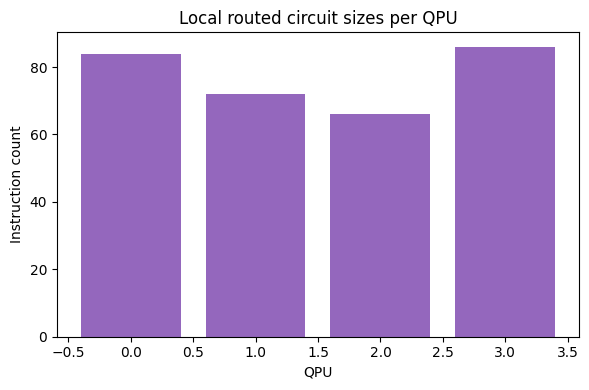

In [8]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6, 4))
plt.bar(local_sizes.keys(), local_sizes.values(), color='tab:purple')
plt.title('Local routed circuit sizes per QPU')
plt.xlabel('QPU')
plt.ylabel('Instruction count')
plt.tight_layout()
plt.show()